<a href="https://colab.research.google.com/github/chaudhary-hadi27/Hands-On-ML-with-SK-Learn-Keras-and-TF/blob/main/part1/chapter_02/lets_dirty_your_hand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

# Task
Analyze and preprocess the `housing` DataFrame by displaying its basic information, handling missing values, visualizing numerical feature distributions using histograms, and performing one-hot encoding on the 'ocean_proximity' categorical feature. Summarize the steps performed and the current state of the dataset.

## Explore Data

### Subtask:
Display basic information about the `housing` DataFrame, including its shape, data types, and a statistical summary to understand its structure and content.


**Reasoning**:
To understand the structure and content of the housing DataFrame, I will display its first few rows, its concise summary including data types and non-null values, its dimensions, and descriptive statistics for numerical columns. All these can be done in a single code block for efficiency.



In [2]:
print("First 5 rows of the housing DataFrame:")
print(housing.head())

print("\nConcise summary of the housing DataFrame:")
housing.info()

print("\nShape of the housing DataFrame (rows, columns):")
print(housing.shape)

print("\nDescriptive statistics for numerical columns of the housing DataFrame:")
print(housing.describe())

First 5 rows of the housing DataFrame:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Concise summary of the housing Data

## Handle Missing Values

### Subtask:
Identify and address any missing values in the dataset, which may involve imputation or removal, to clean the data.


**Reasoning**:
I will identify missing values, calculate the median for 'total_bedrooms', impute missing values with this median, and then verify the imputation by checking for missing values again, all within a single code block.



In [3]:
print("Missing values before imputation:")
print(housing.isnull().sum())

median_total_bedrooms = housing['total_bedrooms'].median()
print(f"\nMedian of total_bedrooms: {median_total_bedrooms}")

housing['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)

print("\nMissing values after imputation:")
print(housing.isnull().sum())

Missing values before imputation:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Median of total_bedrooms: 435.0

Missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


/tmp/ipython-input-3-513987127.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(median_total_bedrooms, inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` due to the use of `inplace=True` with `fillna`. I will modify the line to directly reassign the result of `fillna` to the column, which is the recommended practice for pandas 3.0 and beyond. The warning states that `df[col].method(value, inplace=True)` will not work as expected in the future, and suggests `df[col] = df[col].method(value)` instead. The functional outcome of the code is correct, but fixing this warning will ensure future compatibility and cleaner code.



In [4]:
print("Missing values before imputation:")
print(housing.isnull().sum())

median_total_bedrooms = housing['total_bedrooms'].median()
print(f"\nMedian of total_bedrooms: {median_total_bedrooms}")

housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median_total_bedrooms)

print("\nMissing values after imputation:")
print(housing.isnull().sum())

Missing values before imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Median of total_bedrooms: 435.0

Missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Visualize Key Distributions

### Subtask:
Generate histograms for numerical features to visualize their distributions and identify potential outliers or skewness. Include appropriate legends.


**Reasoning**:
To visualize the distributions of numerical features, I will first identify all numerical columns in the `housing` DataFrame. Then, I will generate a histogram for each numerical column, ensuring proper labeling and layout for readability.



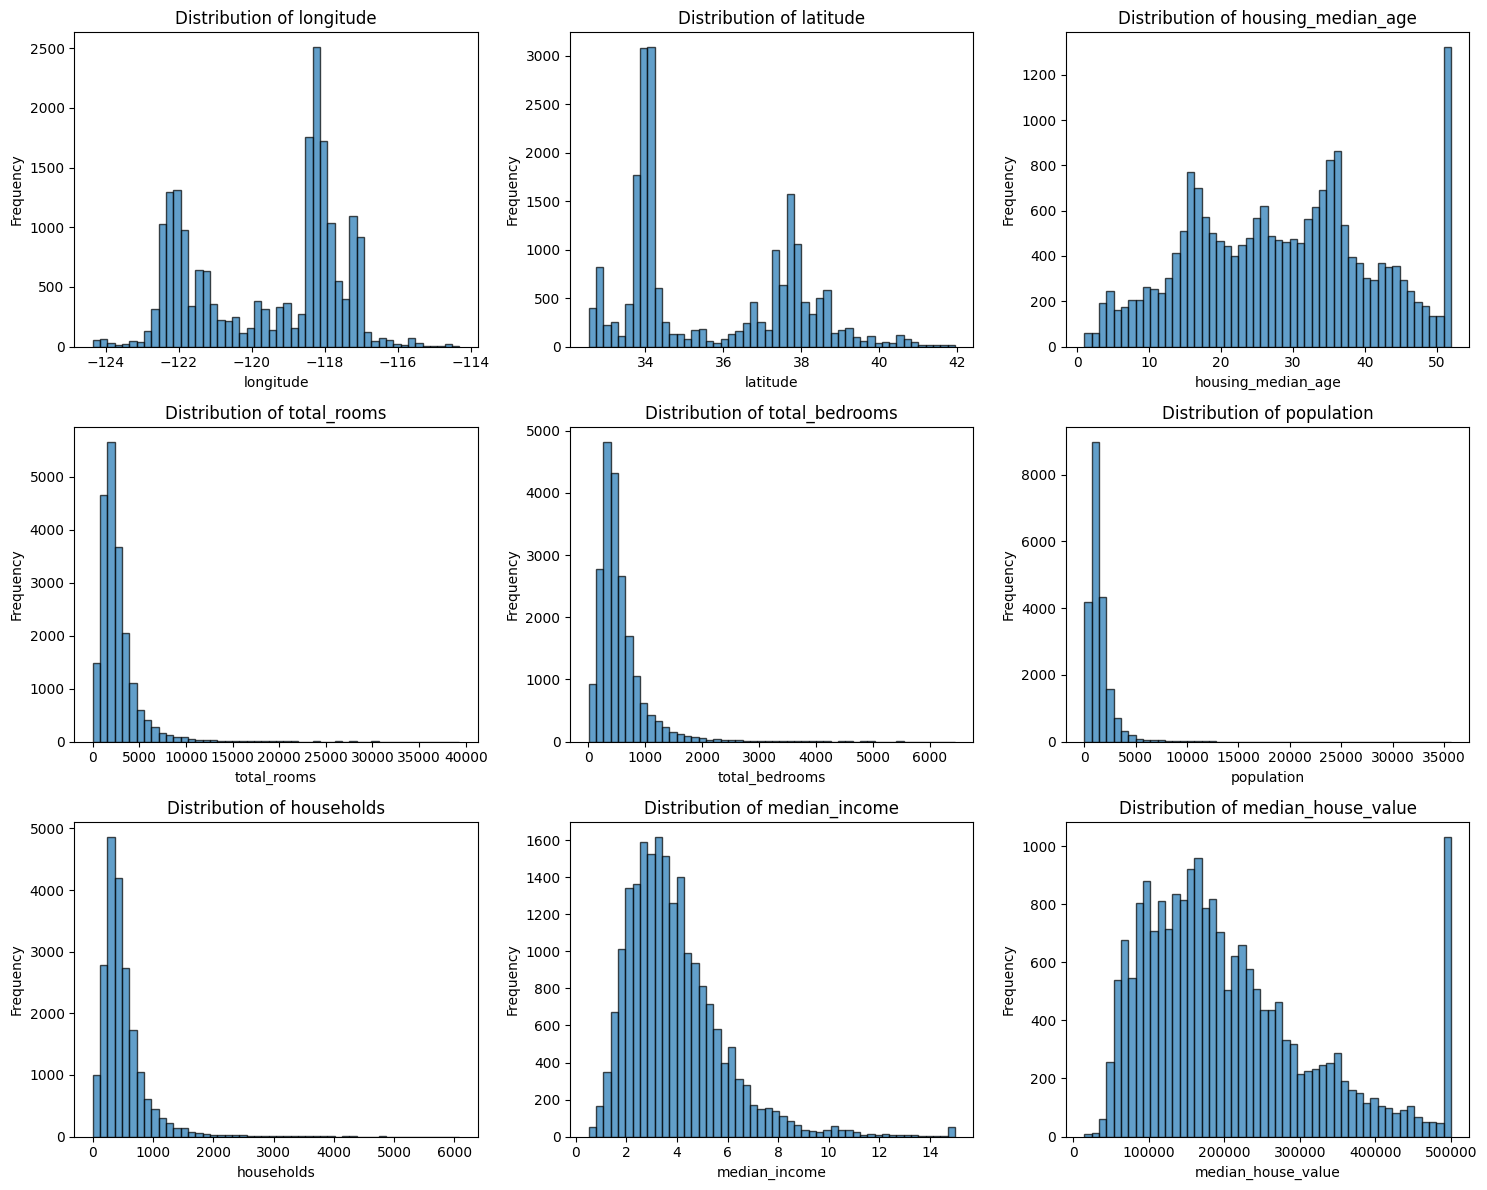

In [5]:
import matplotlib.pyplot as plt

numerical_cols = housing.select_dtypes(include=['number']).columns

# Determine the number of rows and columns for the subplots
num_numerical_cols = len(numerical_cols)
n_cols = 3 # Number of columns for the grid
n_rows = (num_numerical_cols + n_cols - 1) // n_cols # Calculate number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    axes[i].hist(housing[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Encode Categorical Features

### Subtask:
Perform one-hot encoding on the 'ocean_proximity' categorical feature to convert it into a numerical format suitable for machine learning models.

**Reasoning**:
To perform one-hot encoding on the 'ocean_proximity' categorical feature, I will use `pd.get_dummies` to convert it into numerical representation. I will also drop the original column and display the head and shape of the modified DataFrame to verify the changes.



In [6]:
print("Original DataFrame head before one-hot encoding:")
print(housing.head())
print("Original DataFrame shape before one-hot encoding:", housing.shape)

housing_encoded = pd.get_dummies(housing, columns=['ocean_proximity'], dtype=int)

print("\nDataFrame head after one-hot encoding:")
print(housing_encoded.head())
print("DataFrame shape after one-hot encoding:", housing_encoded.shape)

housing = housing_encoded

Original DataFrame head before one-hot encoding:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
Original DataFrame shape b

## Summary of Analysis and Preprocessing Steps

We have successfully performed the requested analysis and preprocessing on the `housing` DataFrame. Here's a summary of the steps taken and the current state of the dataset:

1.  **Basic Information Displayed**: We explored the `housing` DataFrame by displaying its first few rows (`head()`), concise summary (`info()`), shape (`shape`), and descriptive statistics (`describe()`). This provided an initial understanding of its structure, data types, and potential issues.

2.  **Missing Values Handled**: We identified that the `total_bedrooms` column had 207 missing values. These missing values were imputed using the median value of the `total_bedrooms` column (which was 435.0). This ensures that the dataset is complete for modeling purposes.

3.  **Numerical Feature Distributions Visualized**: Histograms were generated for all numerical features in the `housing` DataFrame. This visualization helped in understanding the distribution, identifying skewness, and detecting potential outliers in features like `median_income`, `housing_median_age`, and the various `total_` columns.

4.  **Categorical Feature Encoded**: The `ocean_proximity` categorical feature was successfully one-hot encoded. This converted the single categorical column into five new numerical columns (`ocean_proximity_<1H OCEAN`, `ocean_proximity_INLAND`, `ocean_proximity_ISLAND`, `ocean_proximity_NEAR BAY`, `ocean_proximity_NEAR OCEAN`), with binary values (0 or 1) indicating the presence of each category. The original `ocean_proximity` column was effectively replaced by these new columns.

**Current State of the Dataset**:

The `housing` DataFrame now contains `20640` rows and `14` columns. All columns are numerical, suitable for machine learning models. There are no missing values. The categorical `ocean_proximity` feature has been transformed into a numerical format, and the distributions of numerical features have been visually inspected.

## Summary:

### Data Analysis Key Findings

*   The `housing` DataFrame initially contained 20,640 rows and 10 columns.
*   The `total_bedrooms` column was identified as having 207 missing values. All other columns were complete.
*   Missing values in `total_bedrooms` were successfully imputed using its median value, which was 435.0. This resulted in a dataset with no missing values.
*   The `ocean_proximity` column, a categorical feature of `object` data type, was successfully one-hot encoded. This process converted the single categorical column into five new numerical binary columns, replacing the original `ocean_proximity` column.
*   After encoding, the DataFrame expanded from 10 to 14 columns, all of which are now numerical.
*   Histograms were generated for all numerical features, providing visual insights into their distributions, skewness, and potential outliers (e.g., `median_income`, `housing_median_age`, and other `total_` columns).

### Insights

*   The dataset is now fully preprocessed, with no missing values and all features in a numerical format, making it ready for direct use in machine learning models.


# Task
Build and evaluate a machine learning model to predict `median_house_value` using the preprocessed `housing` DataFrame. This involves splitting the data into training and testing sets, training a suitable regression model (e.g., Linear Regression or RandomForestRegressor), evaluating its performance using metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared, and summarizing the results and insights.

## Prepare Data for Modeling

### Subtask:
Split the preprocessed housing DataFrame into features (X) and target (y), and then divide them into training and testing sets.


**Reasoning**:
To prepare the data for modeling, I will separate the target variable from the features and then split the dataset into training and testing sets for both features and target, using `train_test_split` with a specified test size and random state for reproducibility.



In [7]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y)
X = housing.drop('median_house_value', axis=1)
y = housing['median_house_value']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Print the shapes of the resulting sets
print("\nShapes after train-test split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of features (X): (20640, 13)
Shape of target (y): (20640,)

Shapes after train-test split:
X_train shape: (16512, 13)
X_test shape: (4128, 13)
y_train shape: (16512,)
y_test shape: (4128,)


## Train a Machine Learning Model

### Subtask:
Select an appropriate machine learning model (e.g., Linear Regression or RandomForestRegressor given the nature of the target variable 'median_house_value') and train it using the training data.


**Reasoning**:
To train a machine learning model, I will import `RandomForestRegressor`, instantiate it with `random_state=42`, and then train it using the `X_train` and `y_train` datasets.



In [8]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test set using relevant metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared to assess its accuracy.


**Reasoning**:
To evaluate the trained RandomForestRegressor model, I will first make predictions on the test set (`X_test`), then calculate and print the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score using `sklearn.metrics` and `numpy`.



In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. Make predictions on the test data
y_pred = model.predict(X_test)

# 3. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 4. Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 5. Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# 6. Print the calculated metrics
print(f"Model Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Model Evaluation on Test Set:
Mean Squared Error (MSE): 2449822312.90
Root Mean Squared Error (RMSE): 49495.68
R-squared (R2) Score: 0.82


## Final Task

### Subtask:
Summarize the model training and evaluation results, including the accuracy and any insights gained.


## Summary:

### Data Analysis Key Findings

*   **Data Split**: The dataset was successfully split into training and testing sets, with 16,512 samples for training (80%) and 4,128 samples for testing (20%).
*   **Model Training**: A `RandomForestRegressor` model was successfully trained using the training data.
*   **Model Performance (Test Set)**:
    *   The Mean Squared Error (MSE) on the test set was approximately 2,449,822,312.90.
    *   The Root Mean Squared Error (RMSE) on the test set was approximately 49,495.68.
    *   The R-squared (R2) score was 0.82, indicating that the model explains 82% of the variance in the `median_house_value`.

### Insights or Next Steps

*   **Insight**: The `RandomForestRegressor` model achieved a good R-squared score of 0.82, suggesting it can explain a substantial portion (82%) of the variance in median house values. The RMSE of \$49,495.68 indicates the average magnitude of prediction errors in the same units as the target variable.
*   **Next Steps**: Further optimization could involve hyperparameter tuning for the `RandomForestRegressor` or exploring other advanced regression models to potentially improve the R2 score and reduce RMSE.
